# Multispecies Network

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la

from scipy.integrate import solve_ivp

# Model definition 
def seirs_multispecies(t, y, s, n, d, e, c, m, beta, M):
    """
    Implements SEIRS model with s species and n patches.
    y: state vector of shape (s*4*n,)
    d, e, c, m: lists of length s with rates for each species
    beta: array of shape (s,s,n) with transmission rates between species in each patch
    M: list of s migration matrices of shape (n,n) for each species
    """
    Y = y.reshape((s, 4, n))
    S, E, I, R = Y[:,0,:], Y[:,1,:], Y[:,2,:], Y[:,3,:]
    N = S + E + I + R

    dS = np.zeros((s,n))
    dE = np.zeros((s,n))
    dI = np.zeros((s,n))
    dR = np.zeros((s,n))

    # for each species
    for i in range(s):
        # for each patch
        for p in range(n):
            # Force of infection: sum over species j
            lambda_ip = 0.0
            for j in range(s):
                if N[j,p] > 0:
                    lambda_ip += beta[i,j,p] * I[j,p] / N[j,p]

            # Equations without migration
            dS[i,p] = d[i]*(N[i,p]-S[i,p]) + m[i]*R[i,p] - lambda_ip*S[i,p]
            dE[i,p] = lambda_ip*S[i,p] - (d[i]+e[i])*E[i,p]
            dI[i,p] = e[i]*E[i,p] - (d[i]+c[i])*I[i,p]
            dR[i,p] = c[i]*I[i,p] - (d[i]+m[i])*R[i,p]

        # Add migration for species i
        dS[i,:] += M[i] @ S[i,:]
        dE[i,:] += M[i] @ E[i,:]
        dI[i,:] += M[i] @ I[i,:]
        dR[i,:] += M[i] @ R[i,:]

    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten()])

def compute_Nstar(Mtilde_list, Ntot_list):
    """
    Finds travel equilibrium N* for each species (s,n),
    solving M N* = 0 with N* >= 0 and sum(N*) = Ntot.
    """
    s = len(Mtilde_list)
    n = Mtilde_list[0].shape[0]
    Nstar = np.zeros((s,n))

    for i in range(s):
        Mtilde = Mtilde_list[i]
        colsum = Mtilde.sum(axis=0)
        # build M from Mtilde
        M = Mtilde - np.diag(colsum)

        # nullspace vector (eigenvector for eigenvalue ~0)
        w, v = la.eig(M) # eigvals, eigvecs
        idx = np.argmin(np.abs(w))
        vec = np.real(v[:,idx])
        if np.all(vec <= 0): vec = -vec
        vec = np.abs(vec)
        vec = vec/vec.sum() * Ntot_list[i]
        Nstar[i,:] = vec
    return Nstar

# Build the block matrices A,B,C,G
def assemble_matrices(s, n, Nstar, d, e, c, beta, Mtilde_list):

    SN = s*n
    A = np.zeros((SN,SN))
    B = np.zeros((SN,SN))
    C = np.zeros((SN,SN))
    G = np.zeros((SN,SN))

    def idx(i,p): return p*s+i

    for k in range(n):
        # G_k
        for i in range(s):
            for j in range(s):
                Njk = Nstar[j,k]
                val = 0.0 if Njk==0 else beta[i,j,k]*Nstar[i,k]/Njk
                G[idx(i,k), idx(j,k)] = val
        # C_k
        for i in range(s):
            C[idx(i,k), idx(i,k)] = e[i]
        # A,B blocks
        for j in range(n):
            for i in range(s):
                if j==k:
                    sum_m = Mtilde_list[i][:,k].sum()
                    A[idx(i,k), idx(i,k)] = d[i]+e[i]+sum_m
                    B[idx(i,k), idx(i,k)] = d[i]+c[i]+sum_m
                else:
                    A[idx(i,j), idx(i,k)] = -Mtilde_list[i][j,k]
                    B[idx(i,j), idx(i,k)] = -Mtilde_list[i][j,k]
    return A,B,C,G


def compute_R0(A,B,C,G):
    # Theorem 2.1 of Arino et al
    Ainv = la.inv(A)
    Binv = la.inv(B)
    K = G @ Binv @ C @ Ainv
    vals = la.eigvals(K)
    return max(np.abs(vals))

def build_migration_matrix(n, rate, mode="one-way"):
    """
    Builds migration matrix for ring structure.
    n: number of patches
    rate: migration rate
    mode: "one-way" or "two-way"
    """
    M = np.zeros((n,n))
    if mode == "one-way":
        for p in range(n):
            q = (p-1)%n   # from q→p
            M[p,q] = rate
    elif mode == "two-way":
        for p in range(n):
            q1 = (p-1)%n
            q2 = (p+1)%n
            M[p,q1] = rate
            M[p,q2] = rate
    # Balance diagonal
    for p in range(n):
        M[p,p] = -np.sum(M[:,p])
    return M

# Build Mtilde (useful for migration)
def build_Mtilde(n, rate, mode="one-way"):
    M = np.zeros((n,n))
    if mode=="one-way":
        for p in range(n):
            q = (p-1)%n
            M[p,q] = rate
    elif mode=="two-way":
        for p in range(n):
            M[(p-1)%n,p] = rate
            M[(p+1)%n,p] = rate
    return M

# Run the dynamics
def run_simulation(mode="one-way"):
    M = [build_migration_matrix(n, 0.03, mode=mode)]
    t_span = (0, 500)
    t_eval = np.linspace(*t_span, 1000)
    sol = solve_ivp(seirs_multispecies, t_span, Y0, args=(s,n,d,e,c,m,beta,M), t_eval=t_eval)
    time = sol.t
    I = sol.y[s*n*2:s*n*3,:].reshape(s,n,-1)[0]
    return time, I



In [2]:
# Parameters 
s, n = 1, 15   # one species, 15 patches 

d = [1/75/365]   # lifespan ~ 75 years in days
e = [1/2]        # incubation 2 days
c = [1/4]        # infectious 4 days
m = [1/365]      # immunity ~ 1 year

# Transmission: only within species, same in all patches except first
beta = np.zeros((s,s,n))
beta[0,0,:] = 0.5
beta[0,0,0] = 0.75   # higher in patch 1

# Initial conditions: 1000 per patch, infection in patch 0
S0 = np.full((s,n), 1000.0)
E0 = np.zeros((s,n))
I0 = np.zeros((s,n))
R0 = np.zeros((s,n))
I0[0,0] = 100
S0[0,0] -= 100

Y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten()])

### One-way migration

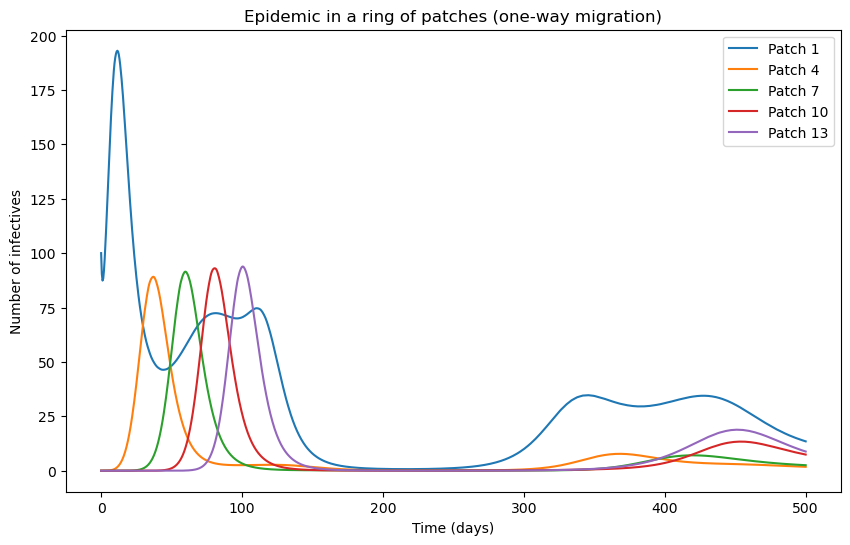

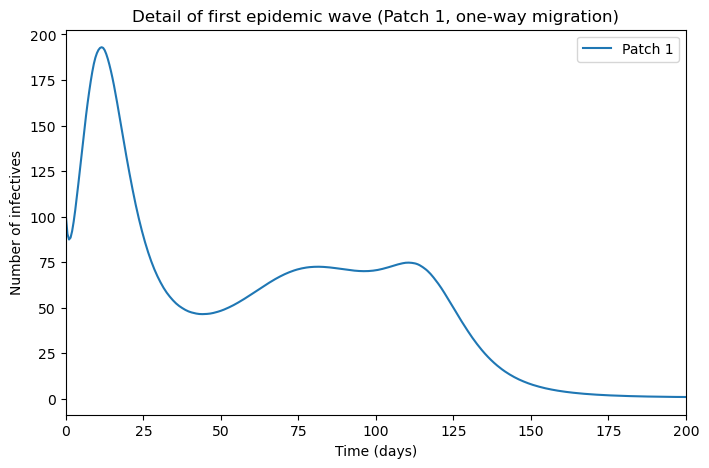

In [3]:
# Run one-way migration
time1, I1 = run_simulation("one-way")

# Plot one-way migration
plt.figure(figsize=(10,6))
for p in range(0,n,3):
    plt.plot(time1, I1[p], label=f"Patch {p+1}")
plt.xlabel("Time (days)")
plt.ylabel("Number of infectives")
plt.title("Epidemic in a ring of patches (one-way migration)")
plt.legend()
plt.show()

# Plot zoom in first epidemic wave for patch 1
plt.figure(figsize=(8,5))
plt.plot(time1, I1[0], label="Patch 1")
plt.xlim(0,200)
plt.xlabel("Time (days)")
plt.ylabel("Number of infectives")
plt.title("Detail of first epidemic wave (Patch 1, one-way migration)")
plt.legend()
plt.show()

### Two-way migration

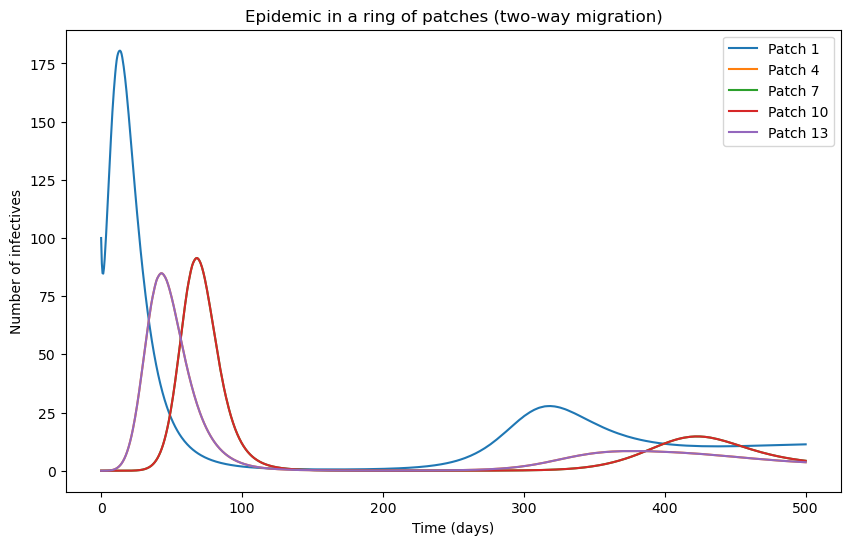

In [4]:
time2, I2 = run_simulation("two-way")

# Plot two-way migration
plt.figure(figsize=(10,6))
for p in range(0,n,3):
    plt.plot(time2, I2[p], label=f"Patch {p+1}")
plt.xlabel("Time (days)")
plt.ylabel("Number of infectives")
plt.title("Epidemic in a ring of patches (two-way migration)")
plt.legend()
plt.show()

### Compute R0

In [5]:
# One species, 15 patches
s,n = 1,15
d = [1/75/365]
e = [1/2]
c = [1/4]
m = [1/365]

beta = np.zeros((s,s,n))
beta[0,0,:] = 0.5
beta[0,0,0] = 0.75


Mtilde_list = [build_Mtilde(n,0.03,"one-way")]
Ntot_list = [1000.0*n]   # total species pop

Nstar = compute_Nstar(Mtilde_list,Ntot_list)
A,B,C,G = assemble_matrices(s,n,Nstar,d,e,c,beta,Mtilde_list)
R0 = compute_R0(A,B,C,G)
print("R0 =", R0)

# The disease is endemic in all connected patches for R0 greater than 1


R0 = 2.5264563893170884


### Check if disease is endemic in all patches

In [6]:
t_span = (0, 1500)
t_eval = np.linspace(*t_span, 1000)

M = [build_migration_matrix(n, 0.03, mode="one-way")]
sol = solve_ivp(seirs_multispecies, t_span, Y0, args=(s,n,d,e,c,m,beta,M), t_eval=t_eval)
I = sol.y[s*n*2:s*n*3,:].reshape(s,n,-1)[0]
E = sol.y[s*n*1:s*n*2,:].reshape(s,n,-1)[0]

# Recover the last value of exposed and infected, should be > 0 for R0 > 1 

for p in range(n):
    print(f'Final E in patch {p+1}: {E[p,-1]:.2f}, Final I in patch {p+1}: {I[p,-1]:.2f}')


Final E in patch 1: 9.92, Final I in patch 1: 18.27
Final E in patch 2: 3.55, Final I in patch 2: 8.28
Final E in patch 3: 1.74, Final I in patch 3: 3.99
Final E in patch 4: 1.08, Final I in patch 4: 2.36
Final E in patch 5: 0.88, Final I in patch 5: 1.82
Final E in patch 6: 0.96, Final I in patch 6: 1.90
Final E in patch 7: 1.35, Final I in patch 7: 2.62
Final E in patch 8: 2.10, Final I in patch 8: 4.03
Final E in patch 9: 2.91, Final I in patch 9: 5.62
Final E in patch 10: 3.35, Final I in patch 10: 6.59
Final E in patch 11: 3.37, Final I in patch 11: 6.72
Final E in patch 12: 3.15, Final I in patch 12: 6.34
Final E in patch 13: 2.89, Final I in patch 13: 5.83
Final E in patch 14: 2.68, Final I in patch 14: 5.42
Final E in patch 15: 2.57, Final I in patch 15: 5.16


### Quarantine

In [7]:
# Migration matrix with quarantine 
def build_migration_matrix_quarantine(
    n, rate, mode="one-way", quarantine_set=None, r_external=1.0, r_internal=1.0 # allow for quarantine of multiple patches
):
    if quarantine_set is None:
        quarantine_set = []
    M = np.zeros((n, n))
    if mode == "one-way":
        for p in range(n):
            q = (p - 1) % n
            M[p, q] = rate
    elif mode == "two-way":
        for p in range(n):
            q1 = (p - 1) % n
            q2 = (p + 1) % n
            M[p, q1] = rate
            M[p, q2] = rate
    if quarantine_set:
        for p in range(n):
            for q in range(n):
                if M[p, q] > 0:
                    if (p in quarantine_set) and (q in quarantine_set):
                        M[p, q] *= r_internal
                    elif (p in quarantine_set) or (q in quarantine_set):
                        M[p, q] *= r_external
    for q in range(n):
        M[q, q] = -np.sum(M[:, q])
    return M

# More compact
def seirs_model(t, y, n, b, d, e, c, m, M):
    S, E, I, R = np.split(y, 4)
    N = S + E + I + R
    
    dS = d*(N - S) + m*R - (b*S*I/N) + M @ S
    dE = (b*S*I/N) - (d+e)*E + M @ E
    dI = e*E - (d+c)*I + M @ I
    dR = c*I - (d+m)*R + M @ R
    
    return np.concatenate([dS, dE, dI, dR])

# Parameters 
n = 15
N0 = 1000 * np.ones(n)
I0 = np.zeros(n); I0[0] = 100
S0 = N0 - I0
E0 = np.zeros(n)
R0 = np.zeros(n)

y0 = np.concatenate([S0, E0, I0, R0])

# rates
d = 1/(75*365)
e = 1/2
c = 1/4
m = 1/365

# transmission rates (patch 0 has higher b)
b = 0.5 * np.ones(n)
b[0] = 0.75

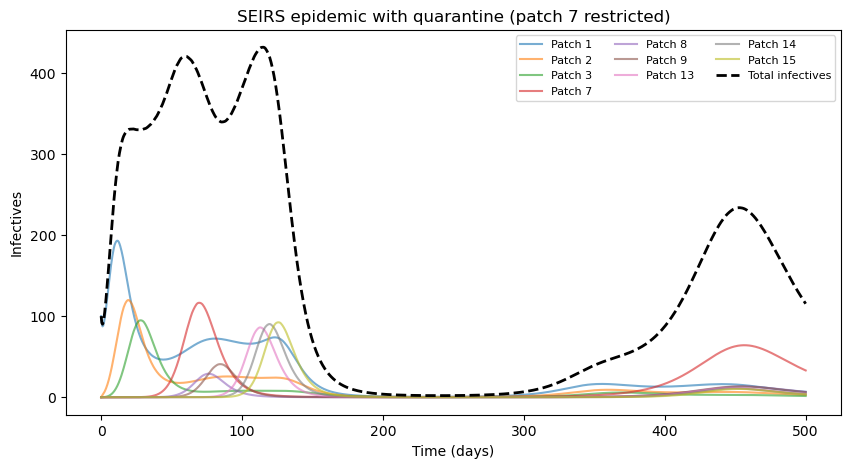

In [8]:
# migration matrix (one-way, with optional quarantine)
M = build_migration_matrix_quarantine(n, rate=0.03, mode="one-way",
                                      quarantine_set=[6], # patch 7
                                      r_external=0.2, r_internal=0.2)

# Solve ODE
t_span = (0, 500)
t_eval = np.linspace(*t_span, 1000)

sol = solve_ivp(seirs_model, t_span, y0, t_eval=t_eval, args=(n, b, d, e, c, m, M))

# Extract results
S, E, I, R = np.split(sol.y, 4)
total_I = I.sum(axis=0)

# Plot 
plt.figure(figsize=(10,5))
for j in [0,1,2,6,7,8,12,13,14]:  # patches 1,2,3 and 7,8,9 and 13,14,15
    plt.plot(sol.t, I[j], label=f"Patch {j+1}", alpha=0.6)
plt.plot(sol.t, total_I, 'k--', lw=2, label="Total infectives")
plt.xlabel("Time (days)")
plt.ylabel("Infectives")
plt.title("SEIRS epidemic with quarantine (patch 7 restricted)")
plt.legend(ncol=3, fontsize=8)
plt.show()


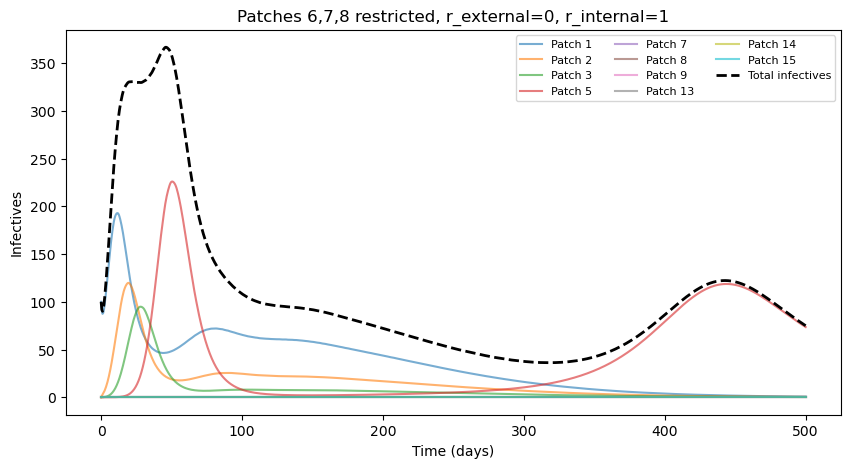

In [11]:
# migration matrix (one-way, with optional quarantine)
M = build_migration_matrix_quarantine(n, rate=0.03, mode="one-way",
                                      quarantine_set=[5,6,7], # patch 7
                                      r_external=0, r_internal=1)

# Solve ODE
t_span = (0, 500)
t_eval = np.linspace(*t_span, 1000)

sol = solve_ivp(seirs_model, t_span, y0, t_eval=t_eval, args=(n, b, d, e, c, m, M))

# Extract results
S, E, I, R = np.split(sol.y, 4)
total_I = I.sum(axis=0)

# Plot
plt.figure(figsize=(10,5))
for j in [0,1,2,4,6,7,8,12,13,14]:  # patches 1,2,3 and 7,8,9 and 13,14,15
    plt.plot(sol.t, I[j], label=f"Patch {j+1}", alpha=0.6)
plt.plot(sol.t, total_I, 'k--', lw=2, label="Total infectives")
plt.xlabel("Time (days)")
plt.ylabel("Infectives")
plt.title("Patches 6,7,8 restricted, r_external=0, r_internal=1")
plt.legend(ncol=3, fontsize=8)
plt.show()


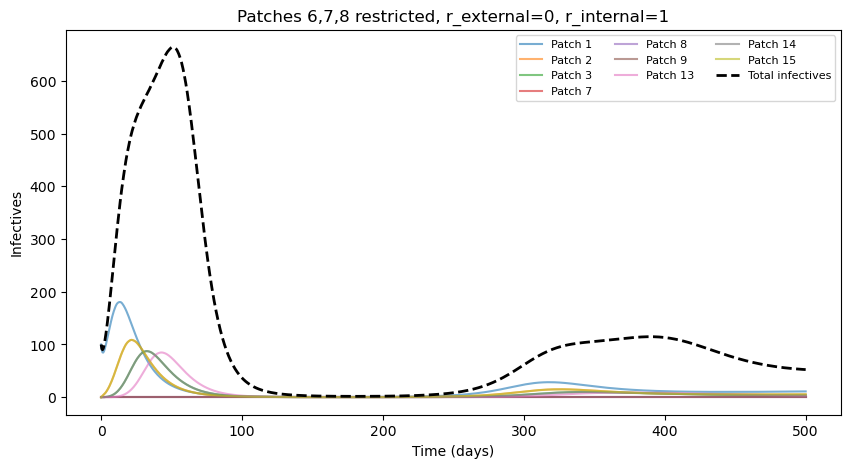

In [23]:
# migration matrix (one-way, with optional quarantine)
M = build_migration_matrix_quarantine(n, rate=0.03, mode="two-way",
                                      quarantine_set=[6,7,8], # patch 7
                                      r_external=0, r_internal=1)

# Solve ODE
t_span = (0, 500)
t_eval = np.linspace(*t_span, 1000)

sol = solve_ivp(seirs_model, t_span, y0, t_eval=t_eval, args=(n, b, d, e, c, m, M))

# Extract results
S, E, I, R = np.split(sol.y, 4)
total_I = I.sum(axis=0)

# Plot
plt.figure(figsize=(10,5))
for j in [0,1,2,6,7,8,12,13,14]:  # patches 1,2,3 and 7,8,9 and 13,14,15
    plt.plot(sol.t, I[j], label=f"Patch {j+1}", alpha=0.6)
plt.plot(sol.t, total_I, 'k--', lw=2, label="Total infectives")
plt.xlabel("Time (days)")
plt.ylabel("Infectives")
plt.title("Patches 6,7,8 restricted, r_external=0, r_internal=1")
plt.legend(ncol=3, fontsize=8)
plt.show()

In [24]:
# Run one simulation
def run_simulation_quarantine(n=15, rate=0.03, mode='one-way',
                   quarantine_set=None, r_factor=1.0,
                   tmax=1000, tsteps=2001, initial_infected_patch=0):
    # epidemiological parameters
    d = 1/(75*365)      # natural death rate (per day)
    e = 1/2             # incubation rate (1/2 days)
    c = 1/4             # recovery rate (1/4 days)
    mu_immunity = 1/365 # loss of immunity (per day)
    # transmission
    b = 0.5 * np.ones(n)
    b[0] = 0.75         # patch 1 has higher transmission

    # initial conditions
    N0 = 1000.0 * np.ones(n)
    I0 = np.zeros(n); I0[initial_infected_patch] = 100.0
    S0 = N0 - I0
    E0 = np.zeros(n); R0 = np.zeros(n)
    y0 = np.concatenate([S0, E0, I0, R0])

    M = build_migration_matrix_quarantine(n, rate, mode=mode,
                                          quarantine_set=quarantine_set,
                                          r_external=r_factor,
                                          r_internal=r_factor)

    t_eval = np.linspace(0, tmax, tsteps)
    sol = solve_ivp(seirs_model, (0, tmax), y0, t_eval=t_eval,
                    args=(n, b, d, e, c, mu_immunity, M),
                    atol=1e-8, rtol=1e-6)

    S, E, I, R = np.split(sol.y, 4)
    total_I = I.sum(axis=0)
    # averages
    avg_total_I = np.trapezoid(total_I, sol.t) / tmax
    avg_I_per_patch = np.trapezoid(I, sol.t, axis=1) / tmax
    min_avg = avg_I_per_patch.min()
    max_avg = avg_I_per_patch.max()
    max_instant = total_I.max()

    return {
        'avg_total_I': avg_total_I,
        'min_avg_patch': min_avg,
        'max_avg_patch': max_avg,
        #'max_instant': max_instant
    }

# Tables
n = 15
rate = 0.03
r_factors = [1.0, 0.5, 0.1, 0.001, 0.0]  # (r = migration multiplier)

# Internally imposed quarantine (patch 7, index 6)
rows_internal = []
for r in r_factors:
    res = run_simulation_quarantine(n=n, rate=rate, mode='one-way',
                         quarantine_set=[6], r_factor=r,
                         tmax=1000, initial_infected_patch=0)
    rows_internal.append({'r_factor': r, **res})
df_internal = pd.DataFrame(rows_internal)

# Externally imposed quarantine (patch 1, index 0)
rows_external = []
for r in r_factors:
    res = run_simulation_quarantine(n=n, rate=rate, mode='one-way',
                         quarantine_set=[0], r_factor=r,
                         tmax=1000, initial_infected_patch=0)
    rows_external.append({'r_factor': r, **res})
df_external = pd.DataFrame(rows_external)

# Print results
print("One-way internal quarantine (patch 7):")
print(df_internal.round(2).to_string(index=False))
print("\nOne-way external quarantine (patch 1):")
print(df_external.round(2).to_string(index=False))


One-way internal quarantine (patch 7):
 r_factor  avg_total_I  min_avg_patch  max_avg_patch
      1.0       112.83           4.05          25.01
      0.5       111.99           3.87          23.31
      0.1       108.94           2.25          25.58
      0.0       106.16           0.06          58.24
      0.0        97.96           0.00          58.89

One-way external quarantine (patch 1):
 r_factor  avg_total_I  min_avg_patch  max_avg_patch
      1.0       112.83           4.05          25.01
      0.5       113.94           3.56          31.67
      0.1       116.80           2.56          39.70
      0.0       106.66           0.45          64.51
      0.0         9.87           0.00           9.87


In [25]:
def build_Mtilde_quarantine(n, rate, mode="one-way",
                            quarantine_set=None,
                            r_external=1.0, r_internal=1.0):
    Mtilde = np.zeros((n,n))
    if mode=="one-way":
        for p in range(n):
            q = (p-1)%n
            Mtilde[p,q] = rate
    elif mode=="two-way":
        for p in range(n):
            Mtilde[(p-1)%n,p] = rate
            Mtilde[(p+1)%n,p] = rate
    if quarantine_set:
        for p in range(n):
            for q in range(n):
                if Mtilde[p,q] > 0:
                    if (p in quarantine_set) and (q in quarantine_set):
                        Mtilde[p,q] *= r_internal
                    elif (p in quarantine_set) or (q in quarantine_set):
                        Mtilde[p,q] *= r_external
    return Mtilde

def compute_Rq(s, n, Ntot_list, d, e, c, m, beta,
               rate=0.03, mode="one-way",
               quarantine_set=None, r_external=1.0, r_internal=1.0):
    Mtilde_list = []
    for i in range(s):
        Mtilde_i = build_Mtilde_quarantine(n, rate, mode,
                                           quarantine_set=quarantine_set,
                                           r_external=r_external,
                                           r_internal=r_internal)
        Mtilde_list.append(Mtilde_i)
    Nstar = compute_Nstar(Mtilde_list, Ntot_list)
    A,B,C,G = assemble_matrices(s,n,Nstar,d,e,c,beta,Mtilde_list)
    return compute_R0(A,B,C,G)

# Parameters
n = 15
rate = 0.03
r_factors = [1.0, 0.5, 0.1, 0.001, 0.0]

# Epidemiological parameters (single species, influenza-like)
s = 1
d = [1/(75*365)]
e = [1/2]
c = [1/4]
m = [1/365]
Ntot_list = [1000*n]
beta = np.zeros((s,s,n))
beta[0,0,:] = 0.5
beta[0,0,0] = 0.75

def build_table(quarantine_patch):
    rows = []
    for r in r_factors:
        sim = run_simulation_quarantine(n=n, rate=rate, mode='one-way',
                             quarantine_set=quarantine_patch,
                             r_factor=r,
                             tmax=1000, initial_infected_patch=0)
        Rq_val = compute_Rq(s,n,Ntot_list,d,e,c,m,beta,
                            rate=rate, mode='one-way',
                            quarantine_set=quarantine_patch,
                            r_external=r, r_internal=r)
        rows.append({'r_factor': r, **sim, 'Rq': Rq_val})
    return pd.DataFrame(rows)

# Internal (patch 7), External (patch 1)
df_internal = build_table([6])
df_external = build_table([0])

print("One-way internal quarantine (patch 7):")
print(df_internal.round(4).to_string(index=False))
print("\nOne-way external quarantine (patch 1):")
print(df_external.round(4).to_string(index=False))


# Rq should remain constant for the internal quarantine scenario
# For r = 0, patch 7 cannot be reached --> matrix is not irreducible 


One-way internal quarantine (patch 7):
 r_factor  avg_total_I  min_avg_patch  max_avg_patch     Rq
    1.000     112.8261         4.0541        25.0071 2.5265
    0.500     111.9945         3.8680        23.3052 2.5265
    0.100     108.9380         2.2522        25.5754 2.5265
    0.001     106.1554         0.0635        58.2401 2.5265
    0.000      97.9587         0.0000        58.8917 1.9996

One-way external quarantine (patch 1):
 r_factor  avg_total_I  min_avg_patch  max_avg_patch     Rq
    1.000     112.8261         4.0541        25.0071 2.5265
    0.500     113.9397         3.5628        31.6745 2.7472
    0.100     116.7969         2.5572        39.6996 2.9461
    0.001     106.6633         0.4487        64.5119 2.9988
    0.000       9.8743         0.0000         9.8743 2.9993


In [26]:
# Tables
n = 15
rate = 0.03
r_factors = [1.0, 0.5, 0.1, 0.001, 0.0]  # (r = migration multiplier)

# Internally imposed quarantine (patch 7, index 6)
rows_internal = []
for r in r_factors:
    res = run_simulation_quarantine(n=n, rate=rate, mode='two-way',
                         quarantine_set=[6], r_factor=r,
                         tmax=1000, initial_infected_patch=0)
    rows_internal.append({'r_factor': r, **res})
df_internal = pd.DataFrame(rows_internal)

# Externally imposed quarantine (patch 1, index 0)
rows_external = []
for r in r_factors:
    res = run_simulation_quarantine(n=n, rate=rate, mode='two-way',
                         quarantine_set=[0], r_factor=r,
                         tmax=1000, initial_infected_patch=0)
    rows_external.append({'r_factor': r, **res})
df_external = pd.DataFrame(rows_external)

# Print results
print("Two-way internal quarantine (patch 7):")
print(df_internal.round(2).to_string(index=False))
print("\nTwo-way external quarantine (patch 1):")
print(df_external.round(2).to_string(index=False))

Two-way internal quarantine (patch 7):
 r_factor  avg_total_I  min_avg_patch  max_avg_patch
      1.0       114.37           6.53          15.65
      0.5       114.31           6.50          15.66
      0.1       114.18           6.47          15.66
      0.0       114.00           6.44          15.66
      0.0       107.08           0.00          15.66

Two-way external quarantine (patch 1):
 r_factor  avg_total_I  min_avg_patch  max_avg_patch
      1.0       114.37           6.53          15.65
      0.5       113.90           6.58          16.74
      0.1       111.36           6.73          13.15
      0.0       107.51           6.61           9.98
      0.0         9.87           0.00           9.87
